In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


In [11]:
df["Campaign_ID"].nunique()
df["Campaign_ID"].unique()

array([    1,     2,     3, ..., 22027, 22028, 22029], shape=(22029,))

In [19]:
df.loc[:,["Location","Customer_Segment"]].drop_duplicates()

,Location,Customer_Segment
0,Houston,Tech Enthusiasts
1,"Washington, D.C.",Foodies
2,Miami,Fashionistas
3,Seattle,Foodies
4,Chicago,Tech Enthusiasts
5,"Washington, D.C.",Outdoor Adventurers
7,Los Angeles,Foodies
8,"Washington, D.C.",Tech Enthusiasts
10,Atlanta,Health & Wellness
11,Dallas,Health & Wellness


In [62]:
df.loc[:,["Campaign_Type","Channel_Used"]].value_counts()


Campaign_Type  Channel_Used
Email          Facebook        767
Search         Facebook        766
               Website         764
Email          Website         764
Display        Email           761
Social Media   Google Ads      757
Influencer     Instagram       753
Display        Google Ads      752
               Instagram       751
Search         Google Ads      750
Influencer     YouTube         747
Social Media   Facebook        744
Influencer     Facebook        743
Social Media   Website         739
               Email           734
Display        Website         733
Search         Email           732
Social Media   YouTube         731
Display        YouTube         731
Search         Instagram       728
Email          Google Ads      723
Display        Facebook        722
Email          YouTube         722
Influencer     Google Ads      712
Email          Instagram       710
Social Media   Instagram       707
Email          Email           702
Search         YouTube     

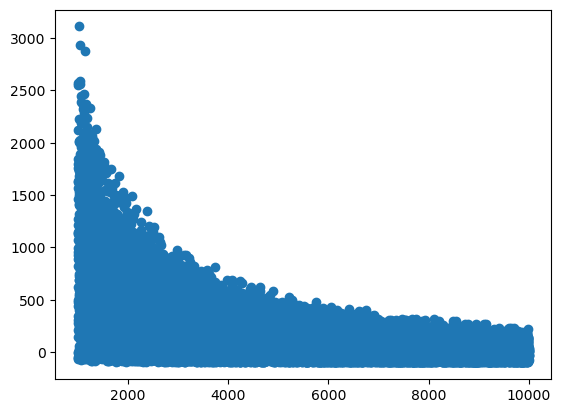

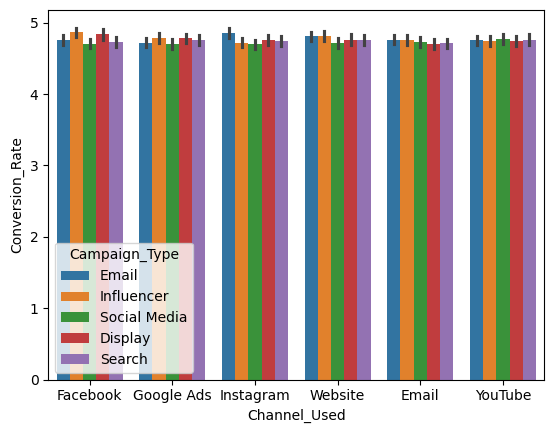

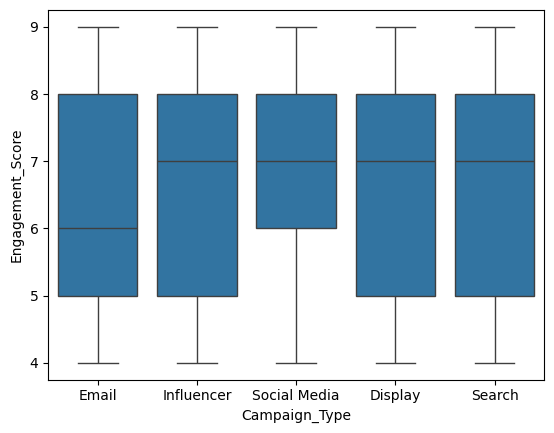

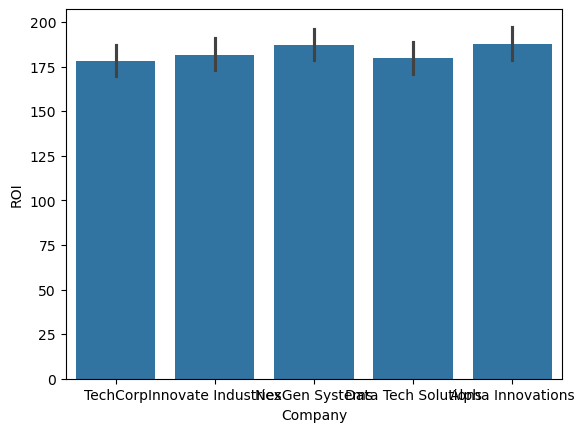

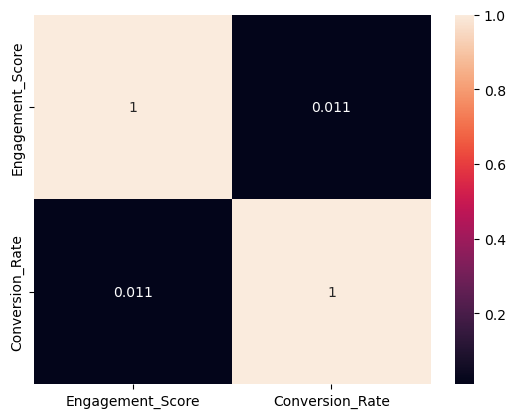

In [39]:
plt.scatter(df["Acquisition_Cost"],df["ROI"])
plt.show()


sns.barplot(data = df,x = "Channel_Used", y = "Conversion_Rate", hue = "Campaign_Type")
plt.show()

sns.boxplot(data = df, x ="Campaign_Type",y ="Engagement_Score")
plt.show()

sns.barplot(data = df, x ="Company", y= "ROI")
plt.show()


corr = df[["Engagement_Score", "Conversion_Rate"]].corr()
sns.heatmap(corr,annot = True)
plt.show()

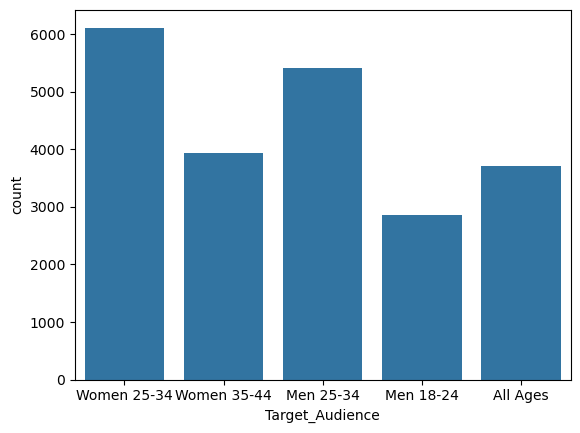

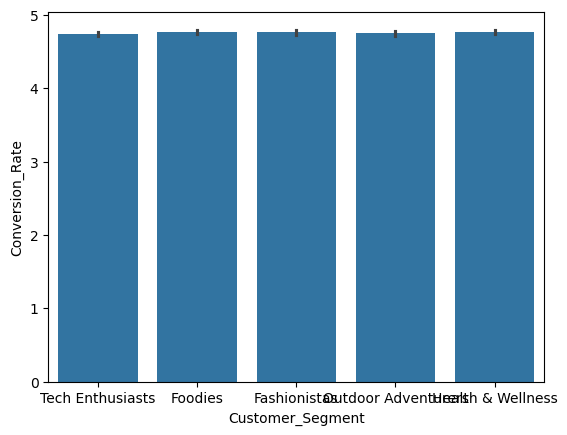

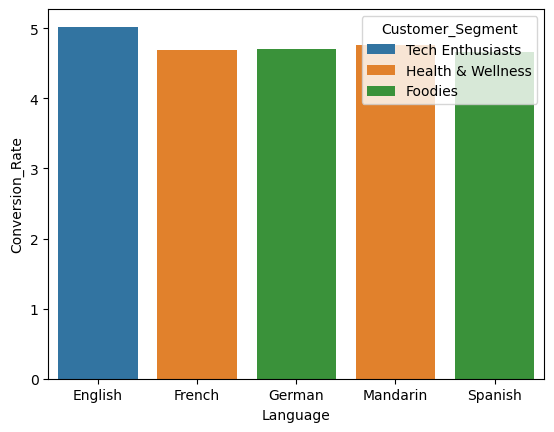

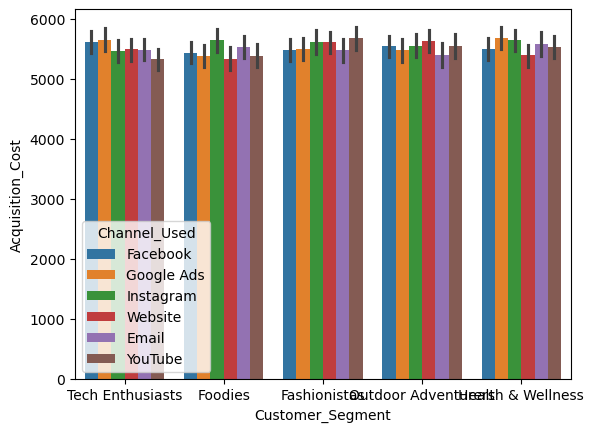

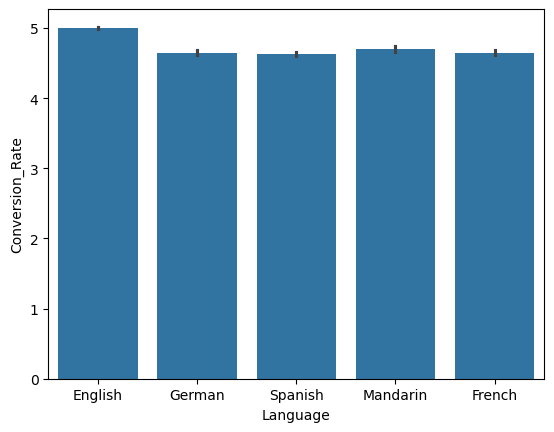

In [51]:
sns.countplot(data = df, x = "Target_Audience")
plt.show()

sns.barplot(data = df, x ="Customer_Segment", y = "Conversion_Rate")
plt.show()


avg = df.groupby(["Language","Customer_Segment"])["Conversion_Rate"].mean().reset_index()
highest = avg.loc[avg.groupby("Language")["Conversion_Rate"].idxmax()]

sns.barplot(data = highest, x = "Language", y = "Conversion_Rate", hue="Customer_Segment")
plt.show()

sns.barplot(data = df, x = "Customer_Segment", y = "Acquisition_Cost", hue = "Channel_Used")
plt.show()

sns.barplot(data = df, x = "Language", y ="Conversion_Rate")
plt.show()

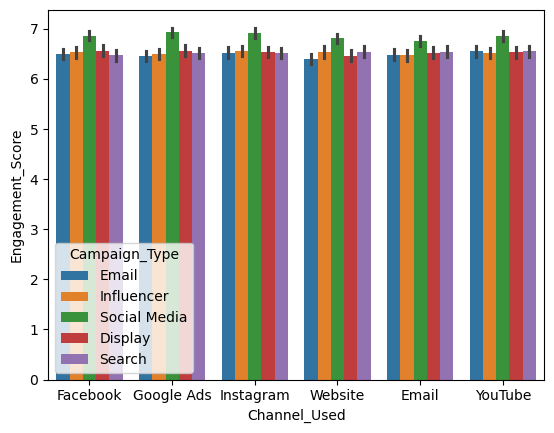

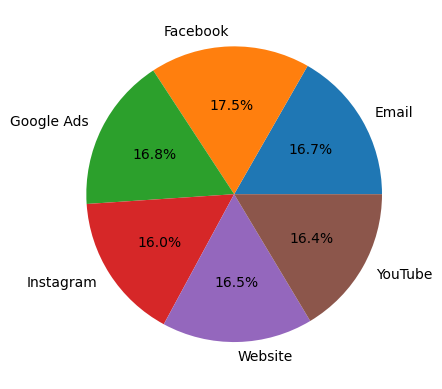

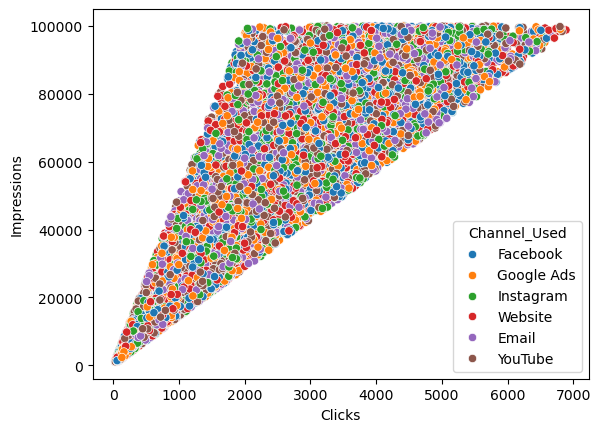

In [52]:
sns.barplot(data=df, x="Channel_Used", y="Engagement_Score", hue="Campaign_Type")
plt.show()

roi = df.groupby("Channel_Used")["ROI"].sum()

plt.pie(roi, labels=roi.index, autopct="%1.1f%%")
plt.show()

sns.scatterplot(data=df, x="Clicks", y="Impressions", hue="Channel_Used")
plt.show()

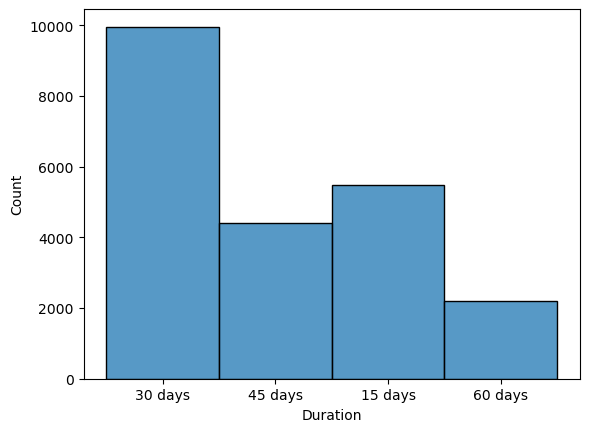

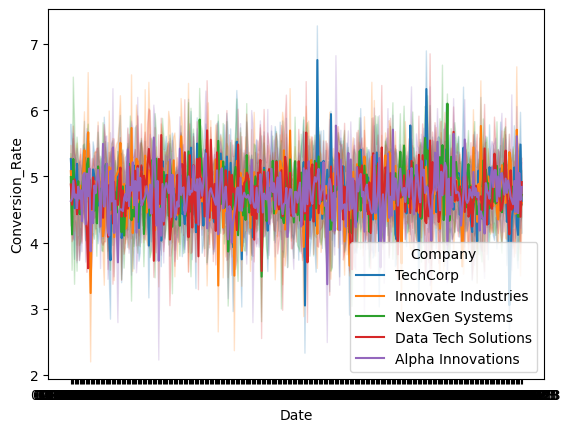

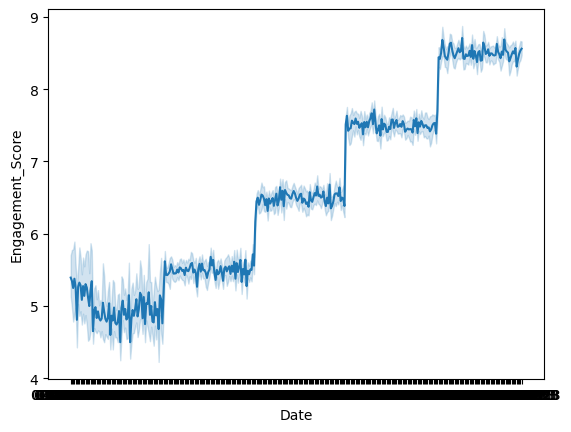

In [61]:
sns.histplot(data=df, x="Duration")
plt.show()

sns.lineplot(data=df, x="Date", y="Conversion_Rate", hue="Company")
plt.show()

sns.lineplot(data=df, x="Date", y="Engagement_Score")
plt.show()

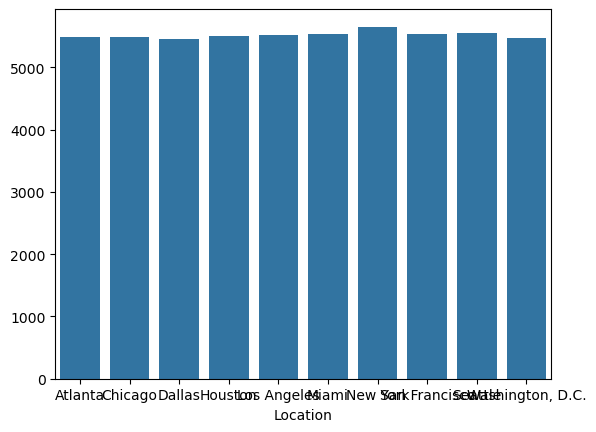

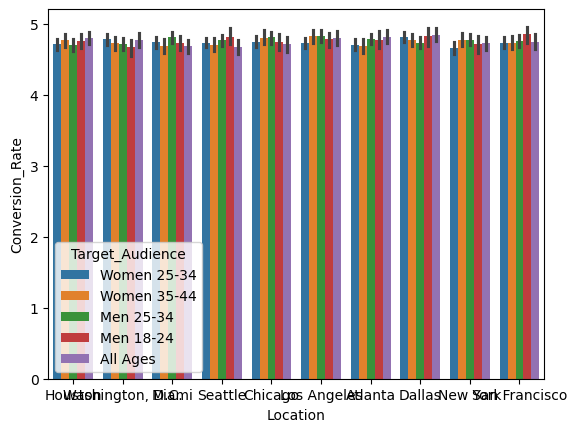

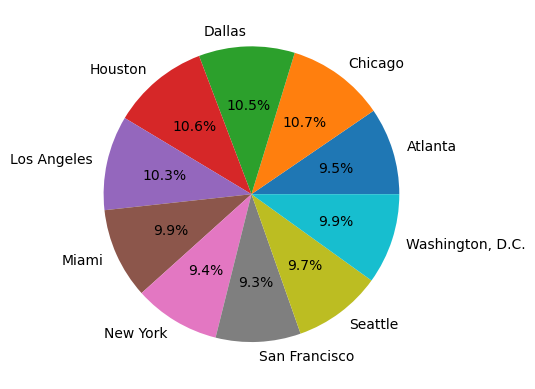

In [60]:
avg = df.groupby("Location")["Acquisition_Cost"].mean()

sns.barplot(x=avg.index, y=avg.values)
plt.show()

sns.barplot(data=df, x="Location", y="Conversion_Rate", hue="Target_Audience")
plt.show()

roi = df.groupby("Location")["ROI"].sum()

plt.pie(roi, labels=roi.index, autopct="%1.1f%%")
plt.show()